# Diabetes and Type Prediction — Research-Grade Revision

This notebook replaces the original single-split, rule-based workflow with a reproducible evaluation pipeline:

- stratified cross-validation
- ROC-AUC, precision, recall, F1, balanced accuracy
- stacking ensemble
- SHAP explainability
- validated K-Means clustering
- proper statistical hypothesis testing for the T3DM section

The notebook is written to be robust to small schema changes in the CSV files.

## 1) Reproducible setup

In [2]:
from __future__ import annotations

import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.multitest import multipletests

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans

import shap

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
np.random.seed(42)

RANDOM_STATE = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [3]:
def find_first_existing_path(candidates):
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path
    raise FileNotFoundError(
        "None of the candidate paths exist:\n" + "\n".join(str(c) for c in candidates)
    )

def load_csv_candidates(candidates, **kwargs):
    path = find_first_existing_path(candidates)
    print(f"Loading: {path}")
    return pd.read_csv(path, **kwargs), path

def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def infer_target_column(df, preferred=("Outcome", "DO", "Target", "Label", "Class")):
    for col in preferred:
        if col in df.columns:
            return col
    raise ValueError(f"No target column found. Available columns: {list(df.columns)}")

def resolve_column(df, candidates):
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None

def encode_binary_target(y):
    if pd.api.types.is_numeric_dtype(y):
        y_num = pd.to_numeric(y, errors="coerce")
        if y_num.nunique(dropna=True) != 2:
            raise ValueError(f"Expected binary target, got {y_num.nunique(dropna=True)} classes.")
        return y_num.astype(int).to_numpy(), None
    le = LabelEncoder()
    y_enc = le.fit_transform(y.astype(str))
    if len(le.classes_) != 2:
        raise ValueError(f"Expected binary target, got {len(le.classes_)} classes: {list(le.classes_)}")
    return y_enc, le

def build_preprocessor(X, scale_numeric=False):
    numeric_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    transformers = []

    if numeric_cols:
        num_steps = [("imputer", SimpleImputer(strategy="median"))]
        if scale_numeric:
            num_steps.append(("scaler", StandardScaler()))
        transformers.append(("num", Pipeline(num_steps), numeric_cols))

    if categorical_cols:
        cat_steps = [
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_one_hot_encoder()),
        ]
        transformers.append(("cat", Pipeline(cat_steps), categorical_cols))

    return ColumnTransformer(transformers=transformers, remainder="drop")

def build_model_pipeline(model, X, scale_numeric=False):
    preprocessor = build_preprocessor(X, scale_numeric=scale_numeric)
    return Pipeline([("preprocess", preprocessor), ("model", model)])

def classification_summary(y_true, y_pred, y_proba=None):
    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_proba is not None:
        out["roc_auc"] = roc_auc_score(y_true, y_proba)
    else:
        out["roc_auc"] = np.nan
    return out

def cohen_d(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    na, nb = len(a), len(b)
    if na < 2 or nb < 2:
        return np.nan
    sa, sb = a.std(ddof=1), b.std(ddof=1)
    pooled = math.sqrt(((na - 1) * sa**2 + (nb - 1) * sb**2) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled if pooled > 0 else np.nan

def rank_biserial_from_u(u, n1, n2):
    return 1.0 - (2.0 * u) / (n1 * n2)

def summarize_shap_values(shap_values):
    if isinstance(shap_values, list):
        return shap_values[1] if len(shap_values) > 1 else shap_values[0]
    if hasattr(shap_values, "values"):
        vals = shap_values.values
        if vals.ndim == 3:
            return vals[..., 1] if vals.shape[-1] > 1 else vals[..., 0]
        return vals
    return shap_values

## 2) Main diabetes classification benchmark

In [4]:
main_candidates = [
    "/kaggle/input/ncsu-diabetes-dataset/Diabetes_DataSet.csv",
    "/kaggle/input/diabetes-dataset/diabetes.csv",
    "Diabetes_DataSet.csv",
    "diabetes.csv",
]

main_df, main_path = load_csv_candidates(main_candidates)
print(main_df.shape)
display(main_df.head())

Loading: /kaggle/input/ncsu-diabetes-dataset/Diabetes_DataSet.csv
(768, 14)


,Pregnancies,Age,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Polyphagia,Visual Blurring,Obesity,Smoker,High Cholestrol (HDL),Diabetes Outcome
0,6,50,148,72,35,0,33.6,0.627,No,No,Yes,1,1,1
1,1,31,85,66,29,0,26.6,0.351,No,Yes,No,1,0,0
2,8,32,183,64,0,0,23.3,0.672,Yes,No,No,0,1,1
3,1,21,89,66,23,94,28.1,0.167,Yes,No,No,0,0,0
4,0,33,137,40,35,168,43.1,2.288,Yes,Yes,Yes,0,1,1


In [5]:
# Clean a few obvious binary yes/no columns while keeping the pipeline robust.
main_df = main_df.copy()

rename_map = {}
if "Diabetes Outcome" in main_df.columns:
    rename_map["Diabetes Outcome"] = "DO"
if rename_map:
    main_df = main_df.rename(columns=rename_map)

for col in main_df.columns:
    if main_df[col].dtype == "object":
        vals = set(main_df[col].dropna().astype(str).str.strip().str.lower().unique())
        if vals == {"yes", "no"}:
            main_df[col] = main_df[col].map({"Yes": 1, "No": 0, "yes": 1, "no": 0})

target_col = infer_target_column(main_df)
print("Target column:", target_col)

X = main_df.drop(columns=[target_col]).copy()
y_raw = main_df[target_col].copy()
y, label_encoder = encode_binary_target(y_raw)

print("X shape:", X.shape)
print("Class balance:", pd.Series(y).value_counts(normalize=True).sort_index())

Target column: DO
X shape: (768, 13)
Class balance: 0    0.651042
1    0.348958
dtype: float64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (614, 13) Test shape: (154, 13)


In [7]:
models = {
    "LogisticRegression": (
        LogisticRegression(max_iter=4000, class_weight="balanced", random_state=RANDOM_STATE),
        True,
    ),
    "RandomForest": (
        RandomForestClassifier(
            n_estimators=500,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        False,
    ),
    "ExtraTrees": (
        ExtraTreesClassifier(
            n_estimators=500,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        False,
    ),
    "GradientBoosting": (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        False,
    ),
    "SVM_RBF": (
        SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE),
        True,
    ),
}

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

cv_rows = []
fitted_pipelines = {}

for name, (model, scale_numeric) in models.items():
    pipe = build_model_pipeline(model, X_train, scale_numeric=scale_numeric)
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=CV,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )
    row = {"model": name}
    for metric in scoring:
        values = scores[f"test_{metric}"]
        row[f"{metric}_mean"] = float(np.mean(values))
        row[f"{metric}_std"] = float(np.std(values))
    cv_rows.append(row)

cv_results = pd.DataFrame(cv_rows).sort_values(by=["roc_auc_mean", "f1_mean"], ascending=False).reset_index(drop=True)
display(cv_results)

cv_results.to_csv("main_model_cv_results.csv", index=False)

,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,SVM_RBF,0.750806,0.018344,0.744626,0.015954,0.623495,0.027602,0.724252,0.017952,0.669767,0.019232,0.825363,0.025905
1,LogisticRegression,0.749154,0.029098,0.741280,0.032742,0.624390,0.044564,0.715061,0.069165,0.664536,0.039672,0.825354,0.034434
2,RandomForest,0.762228,0.029603,0.714378,0.027816,0.705705,0.069729,0.556257,0.036788,0.620412,0.038990,0.820846,0.029827
3,ExtraTrees,0.750820,0.031478,0.688308,0.033081,0.718922,0.091672,0.481617,0.055101,0.573561,0.051477,0.814486,0.028179
4,GradientBoosting,0.752446,0.022132,0.717690,0.013978,0.663573,0.052660,0.602879,0.019048,0.629973,0.015764,0.806548,0.026457


In [8]:
best_model_name = cv_results.loc[0, "model"]
best_model, best_scale_numeric = models[best_model_name]
best_pipeline = build_model_pipeline(best_model, X_train, scale_numeric=best_scale_numeric)
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

test_summary = classification_summary(y_test, y_pred, y_proba)
print("Best model:", best_model_name)
print(pd.Series(test_summary).to_frame("value"))

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, digits=4))

Best model: SVM_RBF
                      value
accuracy           0.727273
balanced_accuracy  0.730370
precision          0.588235
recall             0.740741
f1                 0.655738
roc_auc            0.804074

Classification report:

              precision    recall  f1-score   support

           0     0.8372    0.7200    0.7742       100
           1     0.5882    0.7407    0.6557        54

    accuracy                         0.7273       154
   macro avg     0.7127    0.7304    0.7150       154
weighted avg     0.7499    0.7273    0.7327       154



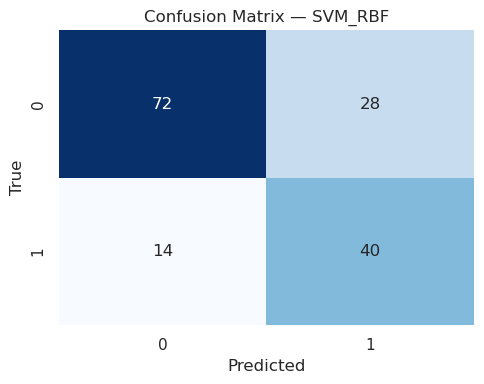

<Figure size 600x500 with 0 Axes>

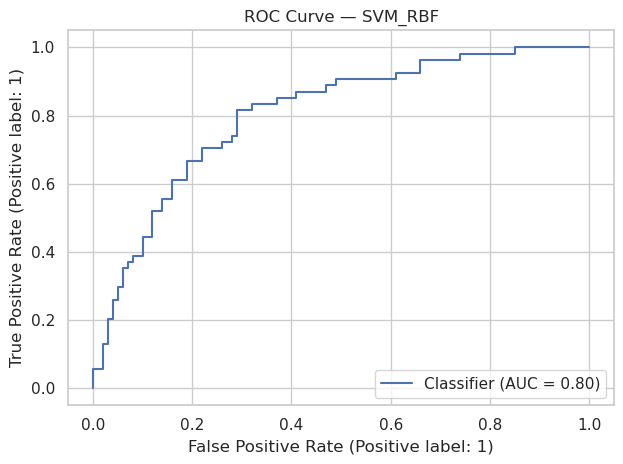

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title(f"ROC Curve — {best_model_name}")
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=200, bbox_inches="tight")
plt.show()

## 3) Stacking ensemble

In [10]:
stacking_estimators = [
    (
        "rf",
        build_model_pipeline(
            RandomForestClassifier(
                n_estimators=400,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
            X_train,
            scale_numeric=False,
        ),
    ),
    (
        "et",
        build_model_pipeline(
            ExtraTreesClassifier(
                n_estimators=400,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
            X_train,
            scale_numeric=False,
        ),
    ),
    (
        "svm",
        build_model_pipeline(
            SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE),
            X_train,
            scale_numeric=True,
        ),
    ),
]

stacking_model = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=LogisticRegression(max_iter=4000, class_weight="balanced", random_state=RANDOM_STATE),
    stack_method="predict_proba",
    passthrough=False,
    n_jobs=1,
)

stacking_pipe = Pipeline([("model", stacking_model)])

stack_scores = cross_validate(
    stacking_pipe,
    X_train,
    y_train,
    cv=CV,
    scoring=scoring,
    n_jobs=1,
    return_train_score=False,
)

stack_row = {"model": "StackingEnsemble"}
for metric in scoring:
    values = stack_scores[f"test_{metric}"]
    stack_row[f"{metric}_mean"] = float(np.mean(values))
    stack_row[f"{metric}_std"] = float(np.std(values))

stacking_summary = pd.DataFrame([stack_row])
display(stacking_summary)

stacking_pipe.fit(X_train, y_train)
stack_pred = stacking_pipe.predict(X_test)
stack_proba = stacking_pipe.predict_proba(X_test)[:, 1]
stack_test_summary = classification_summary(y_test, stack_pred, stack_proba)

print(pd.Series(stack_test_summary).to_frame("value"))
print("\nClassification report:\n")
print(classification_report(y_test, stack_pred, digits=4))

,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,StackingEnsemble,0.760549,0.024287,0.752182,0.01856,0.641072,0.043668,0.724363,0.026384,0.678891,0.022786,0.828066,0.025869


                      value
accuracy           0.727273
balanced_accuracy  0.717593
precision          0.596774
recall             0.685185
f1                 0.637931
roc_auc            0.820000

Classification report:

              precision    recall  f1-score   support

           0     0.8152    0.7500    0.7813       100
           1     0.5968    0.6852    0.6379        54

    accuracy                         0.7273       154
   macro avg     0.7060    0.7176    0.7096       154
weighted avg     0.7386    0.7273    0.7310       154



## 4) SHAP explainability

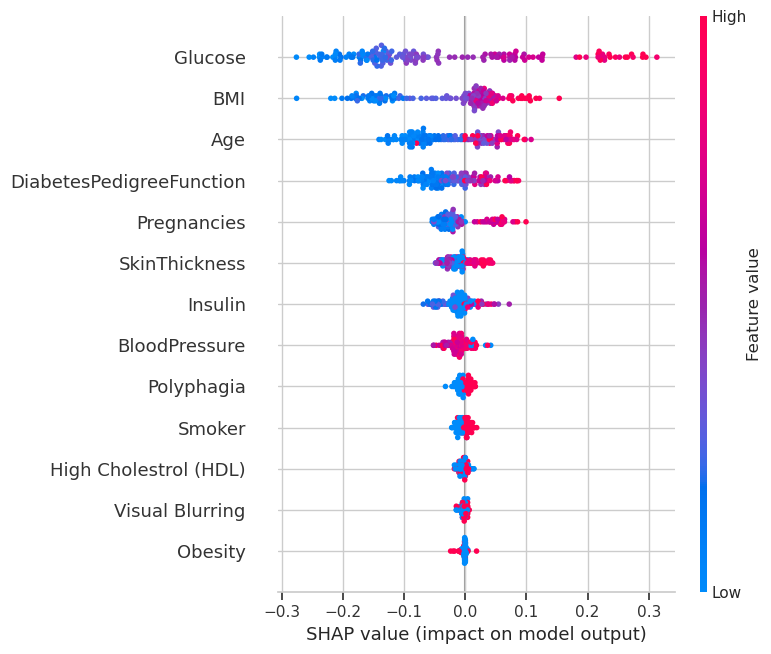

SHAP explained model: RandomForest


In [11]:
# =========================
# SHAP Explainability Cell (Robust & Research-Grade)
# =========================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Helper: Safe feature name extraction (version-robust) ----
def get_feature_names_safe(preprocessor, X):
    try:
        return preprocessor.get_feature_names_out()
    except:
        feature_names = []

        for name, transformer, cols in preprocessor.transformers_:
            if name == "remainder":
                continue

            # If pipeline → take last step
            if hasattr(transformer, "steps"):
                transformer = transformer.steps[-1][1]

            # If transformer supports feature names
            if hasattr(transformer, "get_feature_names_out"):
                try:
                    names = transformer.get_feature_names_out(cols)
                except:
                    names = cols
            else:
                names = cols

            feature_names.extend(names)

        return np.array(feature_names)


# ---- Select best tree-based model from CV results ----
tree_model_names = ["RandomForest", "ExtraTrees", "GradientBoosting"]

tree_ranked = cv_results[
    cv_results["model"].isin(tree_model_names)
].sort_values(by=["roc_auc_mean", "f1_mean"], ascending=False)


if len(tree_ranked) > 0:

    shap_model_name = tree_ranked.iloc[0]["model"]
    shap_model, shap_scale_numeric = models[shap_model_name]

    # Build and fit pipeline
    shap_pipe = build_model_pipeline(
        shap_model,
        X_train,
        scale_numeric=shap_scale_numeric
    )
    shap_pipe.fit(X_train, y_train)

    # Sample data for SHAP (performance-safe)
    sample_X = X_test.sample(min(200, len(X_test)), random_state=RANDOM_STATE)

    preprocessor = shap_pipe.named_steps["preprocess"]
    model = shap_pipe.named_steps["model"]

    # Transform data
    X_trans = preprocessor.transform(sample_X)

    # Convert to dense if sparse
    if hasattr(X_trans, "toarray"):
        X_trans_dense = X_trans.toarray()
    else:
        X_trans_dense = np.asarray(X_trans)

    # Get feature names safely
    feature_names = get_feature_names_safe(preprocessor, sample_X)

    # ---- SHAP Explainer (robust choice) ----
    try:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_trans_dense)
    except:
        explainer = shap.Explainer(model, X_trans_dense)
        shap_values = explainer(X_trans_dense)

    # Handle different SHAP output formats
    if isinstance(shap_values, list):
        shap_matrix = shap_values[1]  # binary classification
    elif hasattr(shap_values, "values"):
        shap_matrix = shap_values.values
    else:
        shap_matrix = shap_values

    # Create DataFrame for plotting
    X_shap_df = pd.DataFrame(X_trans_dense, columns=feature_names)

    # ---- SHAP Summary Plot ----
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_matrix, X_shap_df, show=False, max_display=15)
    plt.tight_layout()
    plt.savefig("shap_summary.png", dpi=200, bbox_inches="tight")
    plt.show()

    print(f"SHAP explained model: {shap_model_name}")

else:
    print("No tree-based model available for SHAP.")

## 5) Validated K-Means clustering

,k,silhouette,calinski_harabasz,davies_bouldin,ari_test,nmi_test
0,4,0.117076,63.683146,2.197218,0.038232,0.030509
1,2,0.116089,70.242869,2.775249,0.102573,0.057791
2,3,0.104950,67.473082,2.421053,0.077002,0.050241
3,7,0.103452,51.931711,2.140581,0.033908,0.047357
4,8,0.100696,48.227595,2.143251,0.023130,0.035904
5,5,0.098834,58.083845,2.199976,0.019693,0.031238
6,6,0.098794,55.948525,2.008235,0.018451,0.028866


Selected k: 4


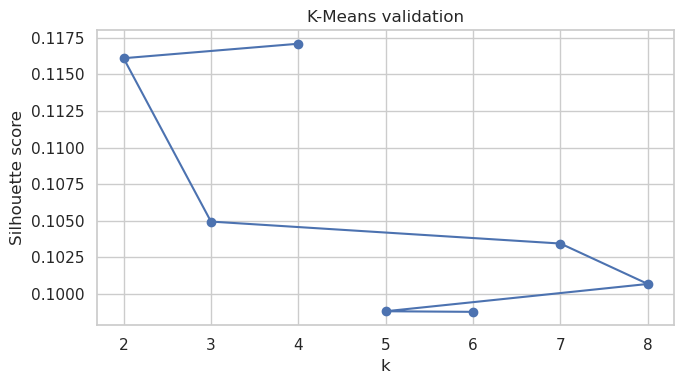

In [12]:
# Internal validation across k, with optional external validation if the target is available.
cluster_preprocessor = build_preprocessor(X_train, scale_numeric=True)
X_train_cluster = cluster_preprocessor.fit_transform(X_train)
X_test_cluster = cluster_preprocessor.transform(X_test)

k_values = range(2, 9)
cluster_rows = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    train_labels = km.fit_predict(X_train_cluster)
    test_labels = km.predict(X_test_cluster)

    row = {
        "k": k,
        "silhouette": silhouette_score(X_train_cluster, train_labels),
        "calinski_harabasz": calinski_harabasz_score(X_train_cluster, train_labels),
        "davies_bouldin": davies_bouldin_score(X_train_cluster, train_labels),
    }

    # External validation against the known class labels is optional but useful.
    row["ari_test"] = adjusted_rand_score(y_test, test_labels)
    row["nmi_test"] = normalized_mutual_info_score(y_test, test_labels)

    cluster_rows.append(row)

cluster_results = pd.DataFrame(cluster_rows).sort_values("silhouette", ascending=False).reset_index(drop=True)
display(cluster_results)

best_k = int(cluster_results.iloc[0]["k"])
print("Selected k:", best_k)

plt.figure(figsize=(7, 4))
plt.plot(cluster_results["k"], cluster_results["silhouette"], marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("K-Means validation")
plt.tight_layout()
plt.savefig("kmeans_silhouette.png", dpi=200, bbox_inches="tight")
plt.show()

## 6) T3DM statistical hypothesis testing

In [13]:
t3dm_candidates = [
    "/kaggle/input/ohio-t3dm-dataset/Ohio_longitudnal_2023_dataset.csv",
    "Ohio_longitudnal_2023_dataset.csv",
]
t3dm_df, t3dm_path = load_csv_candidates(t3dm_candidates)
print(t3dm_df.shape)
display(t3dm_df.head())

Loading: /kaggle/input/ohio-t3dm-dataset/Ohio_longitudnal_2023_dataset.csv
(373, 15)


,Subject ID,Pateint ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,PR-Beta,H1bc-df,Cog-Func,Glycemic Control
0,OAS2_0001,OAS2_0001_MR1,NotPregnant,1,0,F,R,37,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,NotPregnant,2,457,F,R,37,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Pregnant,1,0,F,R,23,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Pregnant,2,560,F,R,23,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Pregnant,3,1895,F,R,32,12,NaN,22.0,0.5,1698,0.701,1.034


In [14]:
# The original notebook used a self-comparison and a hard-coded rule.
# Here we replace that with explicit statistical tests on measurable variables.

group_col = resolve_column(t3dm_df, ["Group"])
sex_col = resolve_column(t3dm_df, ["M/F", "Sex", "Gender"])
gly_col = resolve_column(t3dm_df, ["Glycemic Control"])
cog_col = resolve_column(t3dm_df, ["Cog-Func", "Cognitive Function", "Cognition"])

print("Detected columns:")
print("group_col =", group_col)
print("sex_col   =", sex_col)
print("gly_col   =", gly_col)
print("cog_col   =", cog_col)

analysis_cols = [c for c in [group_col, sex_col, gly_col, cog_col] if c is not None]
analysis_df = t3dm_df[analysis_cols].dropna().copy()
display(analysis_df.head())

Detected columns:
group_col = Group
sex_col   = M/F
gly_col   = Glycemic Control
cog_col   = Cog-Func


,Group,M/F,Glycemic Control,Cog-Func
0,NotPregnant,F,0.883,0.696
1,NotPregnant,F,0.876,0.681
2,Pregnant,F,1.046,0.736
3,Pregnant,F,1.010,0.713
4,Pregnant,F,1.034,0.701


In [15]:
def welch_or_mannwhitney(df, group_col, value_col, group_a, group_b):
    a = pd.to_numeric(df.loc[df[group_col] == group_a, value_col], errors="coerce").dropna().to_numpy()
    b = pd.to_numeric(df.loc[df[group_col] == group_b, value_col], errors="coerce").dropna().to_numpy()

    if len(a) < 3 or len(b) < 3:
        return {
            "test": "insufficient_data",
            "group_a_n": len(a),
            "group_b_n": len(b),
            "statistic": np.nan,
            "p_value": np.nan,
            "effect_size": np.nan,
        }

    normal_a = stats.shapiro(a).pvalue > 0.05 if len(a) <= 5000 else False
    normal_b = stats.shapiro(b).pvalue > 0.05 if len(b) <= 5000 else False

    if normal_a and normal_b:
        stat, p = stats.ttest_ind(a, b, equal_var=False)
        effect = cohen_d(a, b)
        test = "Welch t-test"
    else:
        stat, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        effect = rank_biserial_from_u(stat, len(a), len(b))
        test = "Mann-Whitney U"

    return {
        "test": test,
        "group_a_n": len(a),
        "group_b_n": len(b),
        "statistic": float(stat),
        "p_value": float(p),
        "effect_size": float(effect),
        "group_a_mean": float(np.mean(a)),
        "group_b_mean": float(np.mean(b)),
    }

def omnibus_group_test(df, group_col, value_col):
    tmp = df[[group_col, value_col]].dropna().copy()
    tmp[value_col] = pd.to_numeric(tmp[value_col], errors="coerce")
    tmp = tmp.dropna()

    groups = [g[value_col].to_numpy() for _, g in tmp.groupby(group_col)]
    labels = list(tmp[group_col].dropna().unique())

    if len(groups) < 2:
        return {"test": "insufficient_groups", "p_value": np.nan, "statistic": np.nan, "k_groups": len(groups)}

    normal = all((len(g) >= 3 and (stats.shapiro(g).pvalue > 0.05 if len(g) <= 5000 else False)) for g in groups)
    if normal:
        stat, p = stats.f_oneway(*groups)
        test = "one-way ANOVA"
    else:
        stat, p = stats.kruskal(*groups)
        test = "Kruskal-Wallis"

    return {
        "test": test,
        "k_groups": len(groups),
        "statistic": float(stat),
        "p_value": float(p),
        "labels": labels,
    }

def spearman_test(df, x_col, y_col):
    tmp = df[[x_col, y_col]].dropna().copy()
    tmp[x_col] = pd.to_numeric(tmp[x_col], errors="coerce")
    tmp[y_col] = pd.to_numeric(tmp[y_col], errors="coerce")
    tmp = tmp.dropna()
    if len(tmp) < 3:
        return {"rho": np.nan, "p_value": np.nan, "n": len(tmp)}
    rho, p = stats.spearmanr(tmp[x_col], tmp[y_col])
    return {"rho": float(rho), "p_value": float(p), "n": len(tmp)}

In [16]:
t3dm_results = []

if group_col is not None and gly_col is not None:
    groups = [g for g in t3dm_df[group_col].dropna().astype(str).unique()]
    if len(groups) == 2:
        t3dm_results.append({
            "hypothesis": f"{group_col} difference in {gly_col}",
            **welch_or_mannwhitney(t3dm_df, group_col, gly_col, groups[0], groups[1]),
        })
    elif len(groups) > 2:
        omnibus = omnibus_group_test(t3dm_df, group_col, gly_col)
        t3dm_results.append({
            "hypothesis": f"Omnibus {group_col} effect on {gly_col}",
            **omnibus,
        })

if sex_col is not None and gly_col is not None:
    sex_groups = [g for g in t3dm_df[sex_col].dropna().astype(str).unique()]
    if len(sex_groups) == 2:
        t3dm_results.append({
            "hypothesis": f"{sex_col} difference in {gly_col}",
            **welch_or_mannwhitney(t3dm_df, sex_col, gly_col, sex_groups[0], sex_groups[1]),
        })

if gly_col is not None and cog_col is not None:
    t3dm_results.append({
        "hypothesis": f"Spearman association between {gly_col} and {cog_col}",
        **spearman_test(t3dm_df, gly_col, cog_col),
    })

t3dm_results_df = pd.DataFrame(t3dm_results)

if len(t3dm_results_df) > 0 and "p_value" in t3dm_results_df.columns:
    mask = t3dm_results_df["p_value"].notna()
    if mask.sum() > 0:
        reject, p_adj, _, _ = multipletests(t3dm_results_df.loc[mask, "p_value"].to_numpy(), method="holm")
        t3dm_results_df.loc[mask, "p_value_holm"] = p_adj
        t3dm_results_df.loc[mask, "reject_holm_0.05"] = reject

display(t3dm_results_df)
t3dm_results_df.to_csv("t3dm_hypothesis_tests.csv", index=False)

,hypothesis,test,k_groups,statistic,p_value,labels,rho,n,p_value_holm,reject_holm_0.05
0,Omnibus Group effect on Glycemic Control,Kruskal-Wallis,3.0,1.228223,0.541121,"[NotPregnant, Pregnant, Nondemented]",NaN,NaN,0.541121,False
1,Spearman association between Glycemic Control ...,NaN,NaN,NaN,0.000053,NaN,0.207714,373.0,0.000106,True


## 7) Takeaway

This revision removes the invalid self-comparison used as a fake T3DM accuracy score, and replaces it with:
- cross-validated predictive evaluation
- calibrated ranking metrics including ROC-AUC
- model comparison
- stacking
- SHAP
- unsupervised validation
- explicit hypothesis tests with p-values and effect sizes

In [20]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
et_model = ExtraTreesClassifier(n_estimators=300, random_state=42)
gb_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42)

# Define base models (use your existing tuned versions if you have them)
base_models = [
    ('svm', svm_model),  # SVM-RBF
    ('rf', rf_model),    # Random Forest
    ('et', et_model),    # Extra Trees
    ('gb', gb_model)     # Gradient Boosting
]

# Meta learner (important: simple + regularized)
meta_model = LogisticRegression(max_iter=4000, class_weight='balanced')

# Stacking model
stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    stack_method='predict_proba',  # important
    cv=5,  # internal CV for out-of-fold predictions
    n_jobs=-1,
    passthrough=False
)

# Cross-validation setup (same as your paper)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'bal_acc': 'balanced_accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# Evaluate stacking model
stack_results = cross_validate(
    stack_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

# Print results (mean ± std)
print("\nStacking Ensemble Results (5-fold CV):")
for metric in scoring.keys():
    scores = stack_results[f'test_{metric}']
    print(f"{metric}: {scores.mean():.3f} ± {scores.std():.3f}")


Stacking Ensemble Results (5-fold CV):
accuracy: 0.751 ± 0.039
bal_acc: 0.743 ± 0.030
precision: 0.631 ± 0.056
recall: 0.716 ± 0.007
f1: 0.669 ± 0.033
roc_auc: 0.834 ± 0.026
